## Overview
<p>
A mid-sized technology company is experiencing unexpectedly high employee turnover. The HR
department wants to proactively identify employees who are at risk of leaving (i.e., attrition) so
that targeted retention strategies can be applied. You are provided with a simulated dataset of
3,500 employee records and 19 input features. Your task is to build a Logistic Regression
classification model to predict the binary target variable Attrition.
<p>

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df_train = pd.read_csv('/Users/sukitharathnayake/CodeRepo/ST4035/Data/Assignment 1/ST 4035 Employee Training.csv')
df_test = pd.read_csv('/Users/sukitharathnayake/CodeRepo/ST4035/Data/Assignment 1/ST 4035 Employee Training.csv', index_col='EmployeeID')

In [12]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   EmployeeID                3500 non-null   object
 1   Age                       3500 non-null   int64 
 2   Gender                    3500 non-null   object
 3   Department                3500 non-null   object
 4   JobRole                   3500 non-null   object
 5   YearsAtCompany            3500 non-null   int64 
 6   MonthlyIncome             3500 non-null   int64 
 7   DistanceFromHome          3500 non-null   int64 
 8   NumCompaniesWorked        3500 non-null   int64 
 9   OverTime                  3500 non-null   object
 10  TrainingTimesLastYear     3500 non-null   int64 
 11  WorkLifeBalance           3500 non-null   int64 
 12  JobSatisfaction           3500 non-null   int64 
 13  EnvironmentSatisfaction   3500 non-null   int64 
 14  RelationshipSatisfaction

In [13]:
df_train['EmployeeID'].nunique()

3500

No missing values or duplicates.\
20 columns and 3500 raws.


In [14]:
df_train = pd.read_csv('/Users/sukitharathnayake/CodeRepo/ST4035/Data/Assignment 1/ST 4035 Employee Training.csv', index_col='EmployeeID')

In [15]:
df_train.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Age,3500.0,39.083429,12.343188,18.0,28.0,39.0,50.00,60.0
YearsAtCompany,3500.0,19.682571,11.813333,0.0,10.0,19.0,30.00,40.0
MonthlyIncome,3500.0,10552.667429,5552.778238,1021.0,5732.0,10494.5,15392.75,19984.0
DistanceFromHome,3500.0,15.174286,8.298512,1.0,8.0,15.0,22.00,29.0
NumCompaniesWorked,3500.0,4.527143,2.861099,0.0,2.0,4.0,7.00,9.0
TrainingTimesLastYear,3500.0,3.024286,1.991618,0.0,1.0,3.0,5.00,6.0
WorkLifeBalance,3500.0,2.512571,1.124241,1.0,1.0,3.0,4.00,4.0
JobSatisfaction,3500.0,2.509429,1.121472,1.0,2.0,2.5,4.00,4.0
EnvironmentSatisfaction,3500.0,2.519143,1.129221,1.0,2.0,2.0,4.00,4.0
RelationshipSatisfaction,3500.0,2.494286,1.133663,1.0,1.0,2.0,4.00,4.0


The Dataset consists of 3500 employees and average age of an emplyeee is around 39 years with standard deviation around 12 years. While monthly income shows broad variability with mean of 10552.7 and standard deviation of 5552.8 indicating range of job roles and seniority levels. Also employees have stayed at this particular company for around 20 years on average indicating less attrition among employees.

In [16]:
# Train test split
from sklearn.model_selection import train_test_split

X = df_train.drop('Attrition', axis=1)
y = df_train['Attrition']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# EDA

## Univariate Analysis

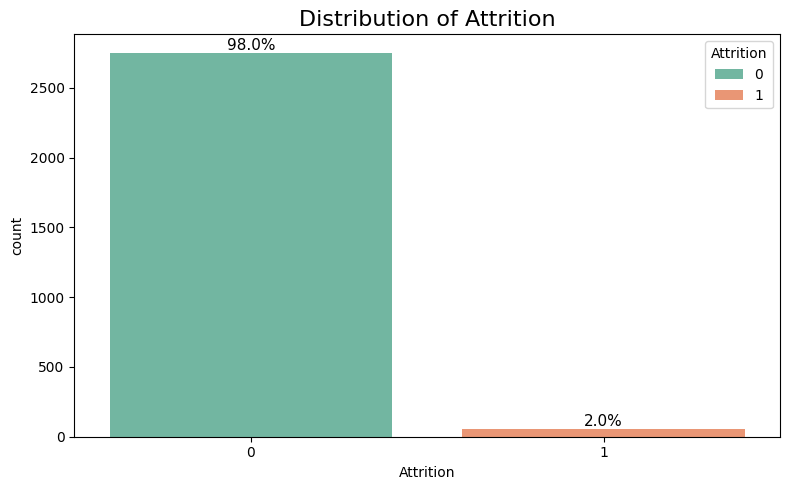

In [17]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x="Attrition", data=X_train.join(y_train), palette='Set2', hue='Attrition', dodge=False)

total = len(y_train)
for container in ax.containers:
    ax.bar_label(container, labels=[f'{v/total*100:.1f}%' for v in container.datavalues], fontsize=11)

plt.title('Distribution of Attrition', fontsize=16)
plt.tight_layout()
plt.show()

Target variable which is attrition is significanly imbalanced, around 98.0% of the target varibale indicating no attrition while around 2% of the target variable indicating attrition.

## Bivariate Analysis

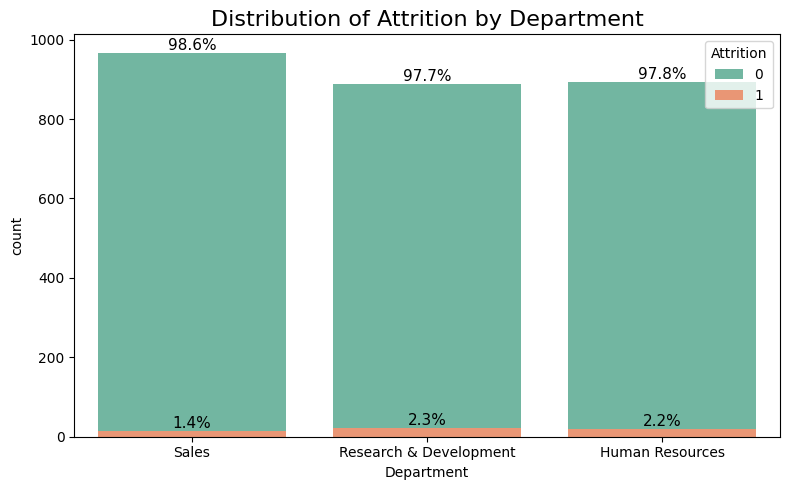

In [18]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x="Department", data=X_train.join(y_train), palette='Set2', hue='Attrition', dodge=False)

department_order = [tick.get_text() for tick in ax.get_xticklabels()]
total_per_department = X_train.join(y_train).groupby("Department")["Attrition"].count()

for container in ax.containers:
    labels = [f'{v/total_per_department[department]*100:.1f}%' for department, v in zip(department_order, container.datavalues)]
    ax.bar_label(container, labels=labels, fontsize=11)

plt.title('Distribution of Attrition by Department', fontsize=16)
plt.tight_layout()
plt.show()

Research and development department shows the highest attrition rate and also it's the smallest department in size. Indicating employyes from research and development department tend to leave the company more compared to other departments.

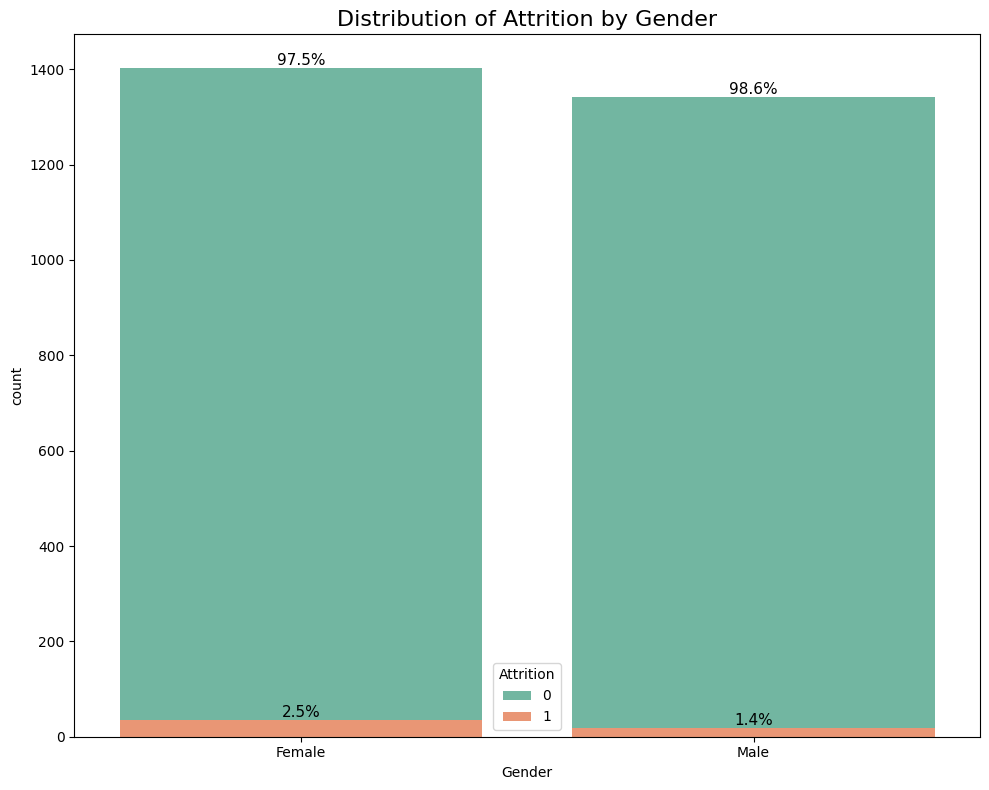

In [19]:
plt.figure(figsize=(10, 8))
ax = sns.countplot(x="Gender", data=X_train.join(y_train), palette='Set2', hue='Attrition', dodge=False)

gender_order = [tick.get_text() for tick in ax.get_xticklabels()]
total_per_gender = X_train.join(y_train).groupby("Gender")["Attrition"].count()

for container in ax.containers:
    labels = [f'{v/total_per_gender[gender]*100:.1f}%' for gender, v in zip(gender_order, container.datavalues)]
    ax.bar_label(container, labels=labels, fontsize=11)

plt.title('Distribution of Attrition by Gender', fontsize=16)
plt.tight_layout()
plt.show()

And when we visualize atrrition rates by gender we can see that majority of the employees are females, and they are more likely to leave the company which is 2.5% of the total female employees.

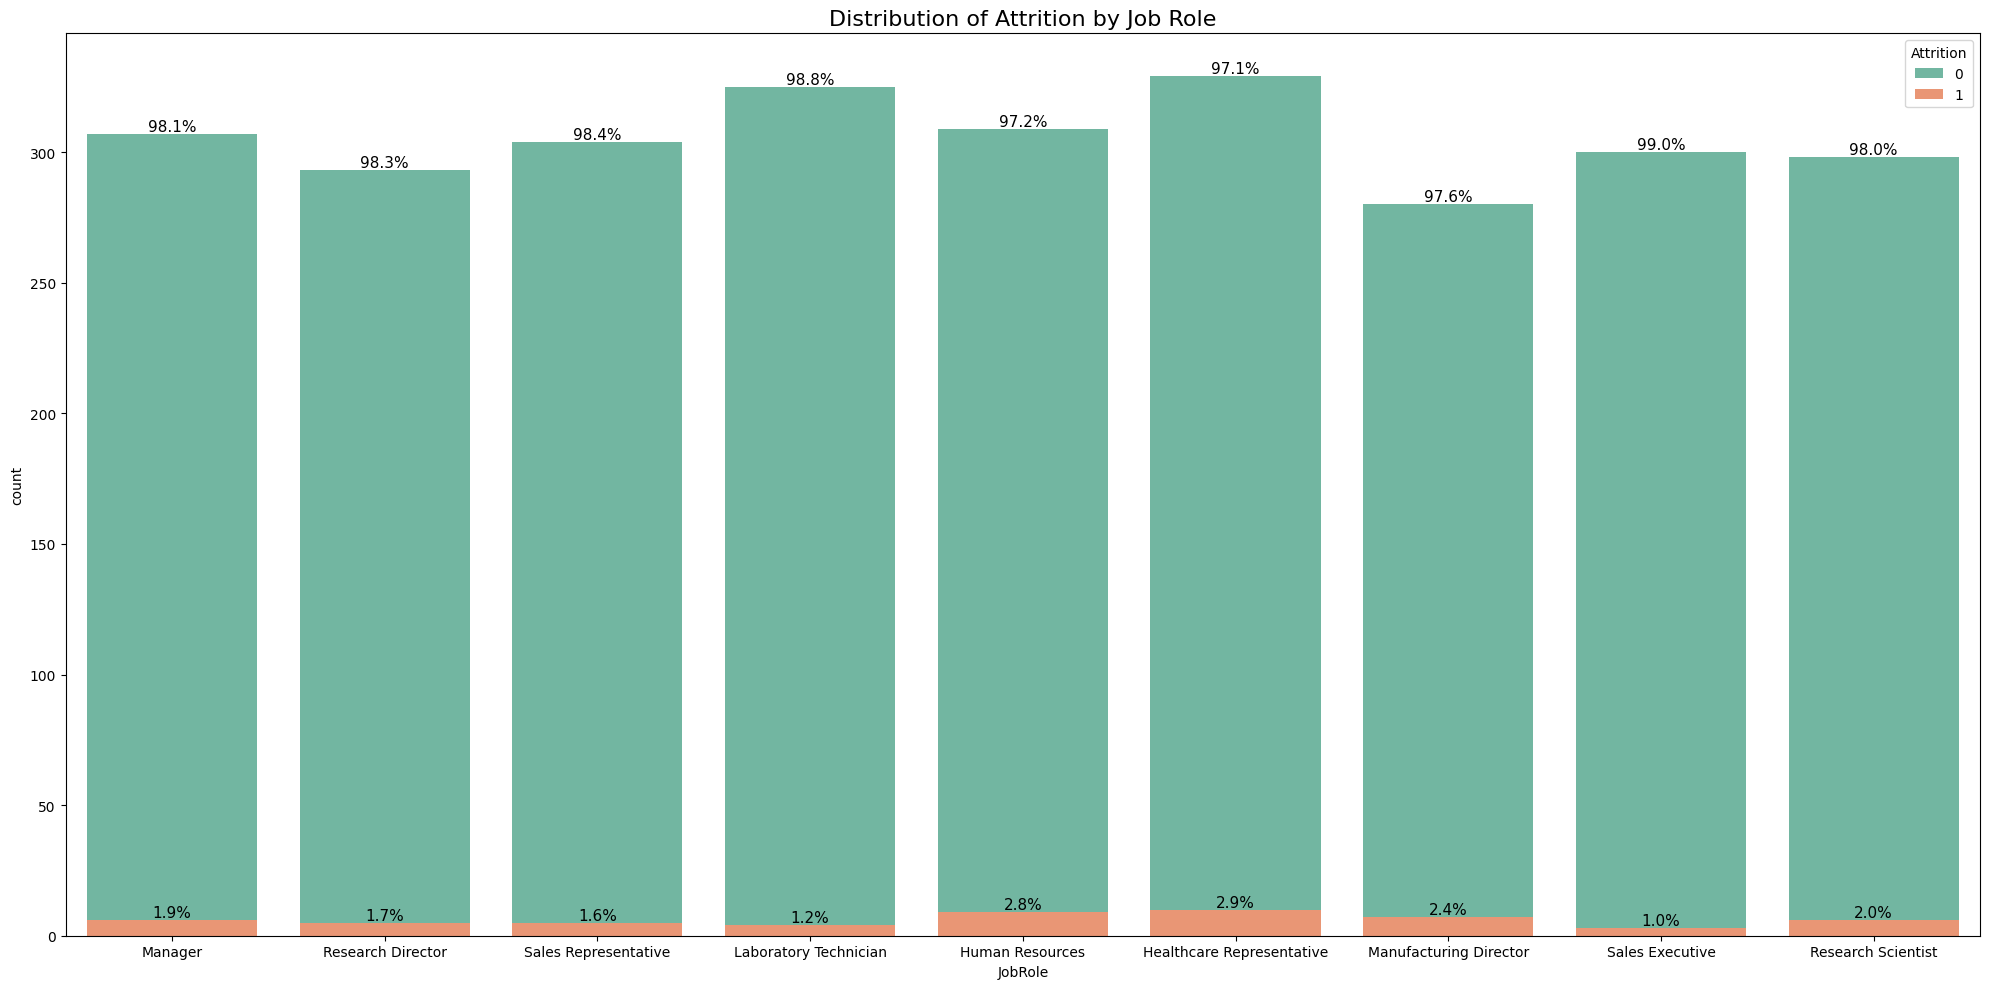

In [20]:
plt.figure(figsize=(20, 10))
ax = sns.countplot(x="JobRole", data=X_train.join(y_train), palette='Set2', hue='Attrition', dodge=False)

jobrole_order = [tick.get_text() for tick in ax.get_xticklabels()]
total_per_jobrole = X_train.join(y_train).groupby("JobRole")["Attrition"].count()

for container in ax.containers:
    labels = [f'{v/total_per_jobrole[jobrole]*100:.1f}%' for jobrole, v in zip(jobrole_order, container.datavalues)]
    ax.bar_label(container, labels=labels, fontsize=11)

plt.title('Distribution of Attrition by Job Role', fontsize=16)
plt.tight_layout()
plt.show()

Healthcare Representatives has the higest number of employees in count and they have the higest persentage of attrition as well. While human resourse employees are less than healthcare representatives in count they have the second higest attrition rate among all the job roles. which is around 2.8% .

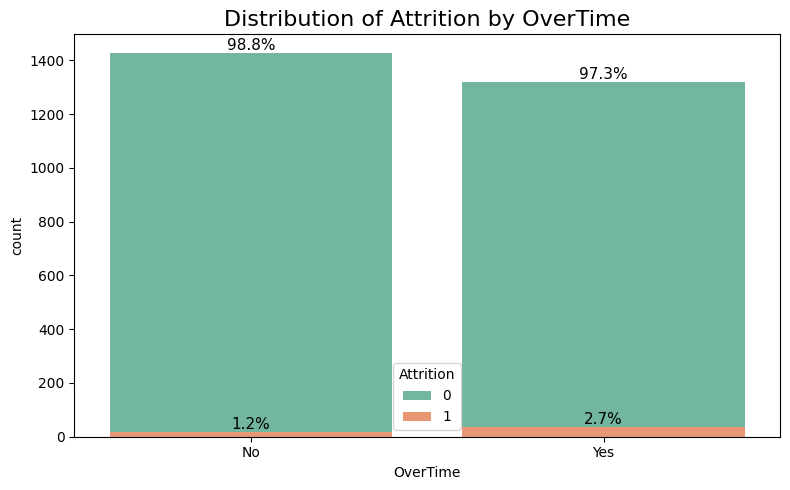

In [21]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x="OverTime", data=X_train.join(y_train), palette='Set2', hue='Attrition', dodge=False)

overtime_order = [tick.get_text() for tick in ax.get_xticklabels()]
total_per_overtime = X_train.join(y_train).groupby("OverTime")["Attrition"].count()

for container in ax.containers:
    labels = [f'{v/total_per_overtime[overtime]*100:.1f}%' for overtime, v in zip(overtime_order, container.datavalues)]
    ax.bar_label(container, labels=labels, fontsize=11)

plt.title('Distribution of Attrition by OverTime', fontsize=16)
plt.tight_layout()
plt.show()

Among the people who are doing overtime 2.7% of them has left the company while 1.2% of the employees who do not do overtime has left the company.

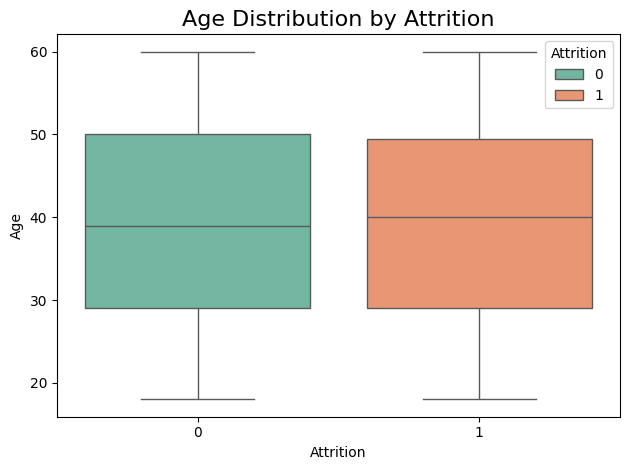

In [22]:
sns.boxplot(x="Attrition", y="Age", data=X_train.join(y_train), palette='Set2', hue='Attrition', dodge=False)
plt.title('Age Distribution by Attrition', fontsize=16)
plt.tight_layout()
plt.show()

From this boxplot we can see that age haven't played significant role when employees leaving the company. And for both people who have left the company and who have stayed median age is around same and the age range is also similar.

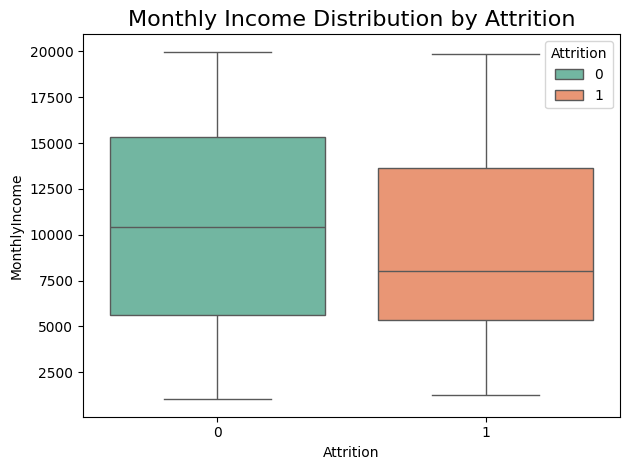

In [23]:
sns.boxplot(x="Attrition", y="MonthlyIncome", data=X_train.join(y_train), palette='Set2', hue='Attrition', dodge=False)
plt.title('Monthly Income Distribution by Attrition', fontsize=16)
plt.tight_layout()
plt.show()

Not like age monthly income has affected whether an employee is going to stay or not, because among the employees who have left the company they have low median monthly income compared to people who have stayed.

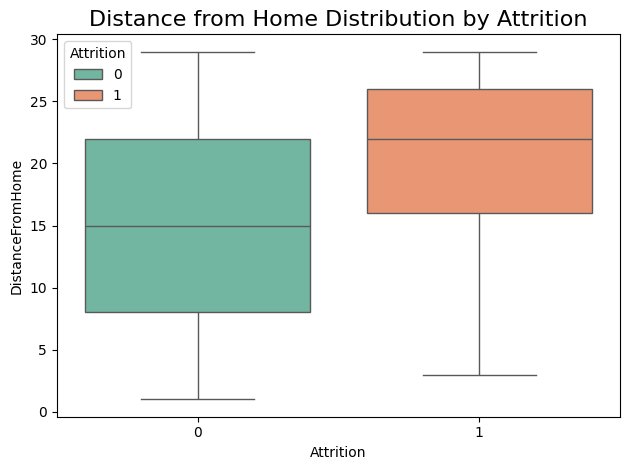

In [24]:
sns.boxplot(x="Attrition", y="DistanceFromHome", data=X_train.join(y_train), palette='Set2', hue='Attrition', dodge=False)
plt.title('Distance from Home Distribution by Attrition', fontsize=16)
plt.tight_layout()
plt.show()

Much like monthly income, distance from home has made noticable impact on whether an employee will leave the company or not. As we can observe higher the distance from home you are more likely to leave the company.

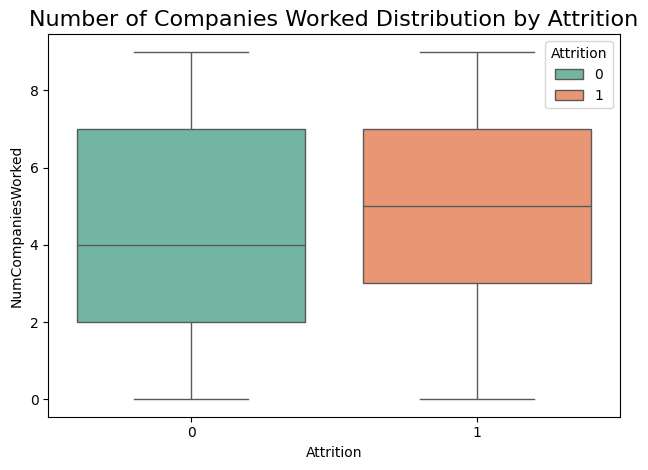

In [25]:
sns.boxplot(x="Attrition", y="NumCompaniesWorked", data=X_train.join(y_train), palette='Set2', hue='Attrition', dodge=False)
plt.title('Number of Companies Worked Distribution by Attrition', fontsize=16)
plt.tight_layout()
plt.show()

Number of companies worked seems to have affected the attrition, but 4 is the median for people who have stayed while 5 is the midean for people who have left. While medians are not telling a convincing story we can see that if a person has higher number of companies he has worked for he has slightly more chance of leaving this company too.

## Multivariate Analysis

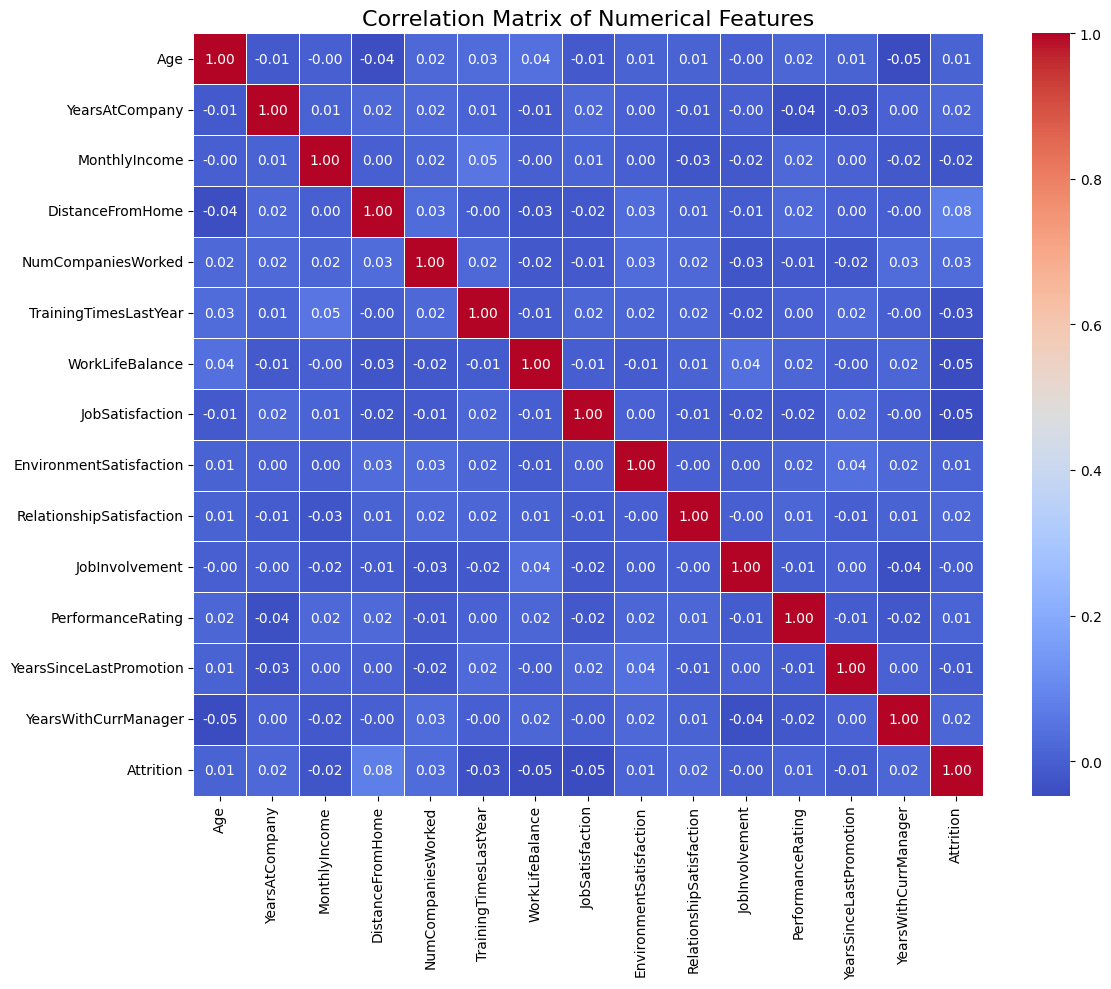

In [26]:
corr_matrix = X_train.join(y_train).select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()


In [27]:
print("Top factors correlated with Attrition:")
print(corr_matrix['Attrition'].sort_values(ascending=False).head(6)) 

Top factors correlated with Attrition:
Attrition                   1.000000
DistanceFromHome            0.076448
NumCompaniesWorked          0.029394
RelationshipSatisfaction    0.021592
YearsAtCompany              0.020152
YearsWithCurrManager        0.016682
Name: Attrition, dtype: float64


In [28]:
print("Factors that make people STAY (Negative Correlation):")
print(corr_matrix['Attrition'].sort_values(ascending=True).head(5))

Factors that make people STAY (Negative Correlation):
WorkLifeBalance           -0.047308
JobSatisfaction           -0.045997
TrainingTimesLastYear     -0.033719
MonthlyIncome             -0.023552
YearsSinceLastPromotion   -0.007198
Name: Attrition, dtype: float64


From the correlation matrix we can see that there is no significant correlation among atrrition and other variables. But among those variables distance from home has the higest correlation with atrrition which is 0.076 and worklife balance has the higest negative correlation. which is -0.047.

In [29]:
#Feature Engineering

def engineer_features(df):
    df = df.copy()
    
    df['TenurePerCompany']    = df['YearsAtCompany'] / (df['NumCompaniesWorked']+1)
    df['PromotionStagnation'] = df['YearsSinceLastPromotion'] / (df['YearsAtCompany']+1)
    df['ManagerStability']    = df['YearsWithCurrManager'] / (df['YearsAtCompany']+1)
    df = df.drop(columns=['YearsAtCompany', 'NumCompaniesWorked', 'YearsSinceLastPromotion', 'YearsWithCurrManager'])
    return df

X_train = engineer_features(X_train)
X_val   = engineer_features(X_val)
df_test = engineer_features(df_test)

In [30]:
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

In [31]:
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
encoded_columns = X_train_encoded.columns

X_val_encoded   = pd.get_dummies(X_val,   columns=categorical_cols, drop_first=True).reindex(columns=encoded_columns, fill_value=0)
df_test_encoded = pd.get_dummies(df_test, columns=categorical_cols, drop_first=True).reindex(columns=encoded_columns, fill_value=0)

In [32]:
test_index = df_test.index

In [33]:
from sklearn.preprocessing import MinMaxScaler

scaler         = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_val_scaled   = scaler.transform(X_val_encoded)
X_test_scaled  = scaler.transform(df_test_encoded)

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score

In [35]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS


logit_fs = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

sfs = SFS(logit_fs,
          k_features='best',  
          forward=True,       
          floating=False,     
          scoring='f1',       
          cv=5,               
          n_jobs=-1,          
          verbose=1)

sfs.fit(X_train_scaled, y_train)

selected_idx   = list(sfs.k_feature_idx_)
feature_names  = X_train_encoded.columns.tolist()
selected_names = [feature_names[i] for i in selected_idx]

print(f"\nSelected {len(selected_idx)} out of {X_train_scaled.shape[1]} features:")
print(selected_names)


X_train_scaled = X_train_scaled[:, selected_idx]
X_val_scaled   = X_val_scaled[:,   selected_idx]
X_test_scaled  = X_test_scaled[:,  selected_idx]

ModuleNotFoundError: No module named 'mlxtend'

In [ ]:
logit = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
logit.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [ ]:
y_val_proba = logit.predict_proba(X_val_scaled)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores  = [f1_score(y_val, (y_val_proba >= t).astype(int)) for t in thresholds]


best_thresh = thresholds[np.argmax(f1_scores)]
print(f"Best threshold based on F1 score: {best_thresh:.2f}")

Best threshold based on F1 score: 0.70



Validation Results
              precision    recall  f1-score   support

           0       0.99      0.93      0.96       686
           1       0.11      0.43      0.18        14

    accuracy                           0.92       700
   macro avg       0.55      0.68      0.57       700
weighted avg       0.97      0.92      0.94       700

[[639  47]
 [  8   6]]


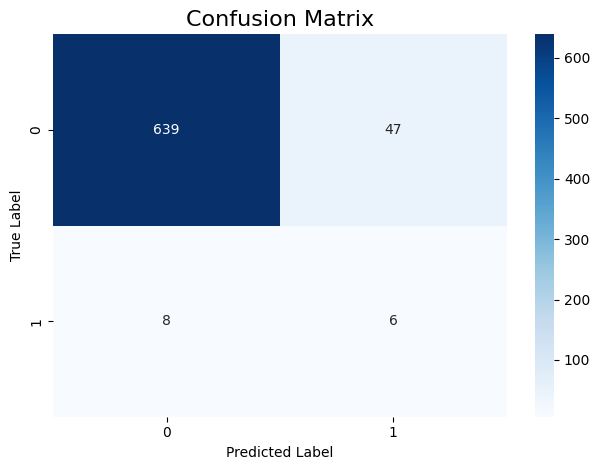

In [ ]:
y_val_pred_tuned = (y_val_proba >= best_thresh).astype(int)
print("\nValidation Results")
print(classification_report(y_val, y_val_pred_tuned))
print(confusion_matrix(y_val, y_val_pred_tuned))

conf_matrix = confusion_matrix(y_val, y_val_pred_tuned)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show() 


In [ ]:
coef_df = pd.DataFrame({
    'Feature':     selected_names,
    'Coefficient': logit.coef_[0],
    'Odds Ratio': np.exp(logit.coef_[0])
}).sort_values('Coefficient', ascending=False)

print(coef_df.to_string(index=False))

                         Feature  Coefficient  Odds Ratio
                DistanceFromHome     1.964081    7.128358
                    OverTime_Yes     0.760282    2.138880
        RelationshipSatisfaction     0.416168    1.516141
BusinessTravel_Travel_Frequently     0.174189    1.190280
                 JobRole_Manager    -0.058551    0.943130
      JobRole_Research Scientist    -0.200485    0.818334
                Department_Sales    -0.464484    0.628459
                 JobSatisfaction    -0.987785    0.372401
                 WorkLifeBalance    -0.996576    0.369141


<p style="font-size: 5px;">

$$
\log\text{-odds}(\text{Attrition}) = \beta_0 
+ 1.964 \cdot \text{DistanceFromHome} 
+ 0.760 \cdot \text{OverTime\_Yes} 
+ 0.416 \cdot \text{RelationshipSatisfaction} 
+ 0.174 \cdot \text{BusinessTravel\_Frequently} 
$$
$$
- 0.059 \cdot \text{JobRole\_Manager}
- 0.200 \cdot \text{JobRole\_ResearchScientist} 
- 0.464 \cdot \text{Department\_Sales} 
- 0.988 \cdot \text{JobSatisfaction} 
- 0.997 \cdot \text{WorkLifeBalance}
$$

</p>

When DistanceFromHome increase by 1 unit, log ods of atrrition increase by 1.96\
Odds of atrrition is 2.1 times moref or employees who are doing overtime compared to odds of attrition for employees who do not do overtime\
when BusinessTravel_Travel_Frequently increase by 1 unit, log ods of attrition increase by 0.17\
Odds of attrition is 1.1 times less for employees with JobRole Manager, compared to odds of attrion for employees with other job roles\
Odds of attrition is 1.2 times less for employees with JobRole Research Scientist, compared to odds of attrion for employees with other job roles\
Odds of attrition is 1.6 times less for employees in JobRole Department Sales, compared to odds of attrion for employees with other Departments\
when JobSatisfaction increase by 1 unit, log ods of attrition decreese by 0.99\
when WorkLifeBalance increase by 1 unit, log ods of attrition decreese by 1


In [ ]:
y_test_proba = logit.predict_proba(X_test_scaled)[:, 1]
y_test_pred  = (y_test_proba >= best_thresh).astype(int)

submission = pd.DataFrame({
    'EmployeeID': test_index,
    'Attrition' : y_test_pred
})

submission.to_csv('submission.csv', index=False)